<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-6/6.6_Logistic%20Regression-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files

uploaded = files.upload()

Saving binary.csv to binary.csv


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
df = pd.read_csv("binary.csv")

In [30]:
X = df[['gre', 'gpa', 'rank']]
y = df['admit']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.675


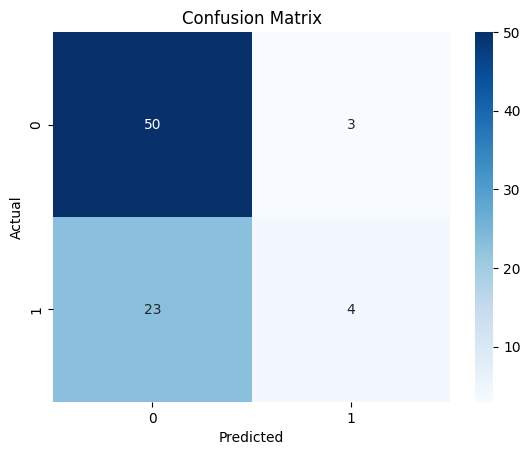

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.94      0.79        53
           1       0.57      0.15      0.24        27

    accuracy                           0.68        80
   macro avg       0.63      0.55      0.51        80
weighted avg       0.65      0.68      0.61        80



In [39]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(['GRE','GPA','Rank'], model.coef_[0]):
    print(feature, ":", coef)

Intercept:
[-0.89120967]

Coefficients:
GRE : 0.20025737515365566
GPA : 0.3301978896399835
Rank : -0.5774846969676924


In [40]:
new_student = pd.DataFrame({
    'gre':[700],
    'gpa':[3.8],
    'rank':[1]
})

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

probability = model.predict_proba(new_student_scaled)

print("Prediction:", prediction[0])

print("Probability of Admission:", probability[0][1])

Prediction: 1
Probability of Admission: 0.6357693088627647
